In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from features import build_features

df = pd.read_csv('dataset.csv')
df = build_features(df)
df['label'].value_counts()

,count
label,
0,902
1,95


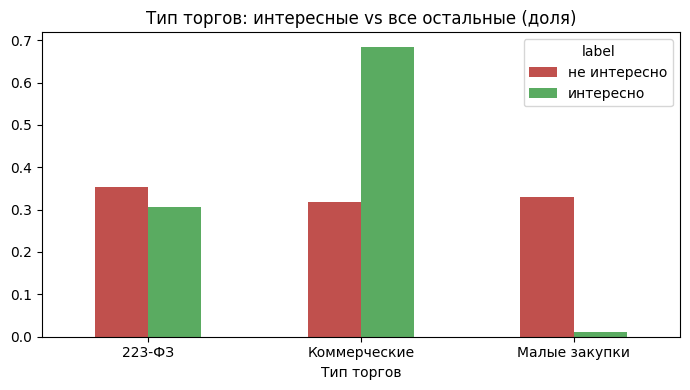

In [4]:
share = pd.crosstab(df['тип_торгов'], df['label'], normalize='columns')
if len(share.columns) == 1:
    share.columns = ['интересно']
else:
    share.rename(columns={0:'не интересно',1:'интересно'}, inplace=True)
share.plot(kind='bar', color=['#c0504d', '#5aab61'], figsize=(7,4))
plt.title('Тип торгов: интересные vs все остальные (доля)')
plt.xlabel('Тип торгов')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Коммерческие среди интересных - 69%, среди остальных - 30%. Малые закупки среди интересных - 0.6%, среди остальных - 36%

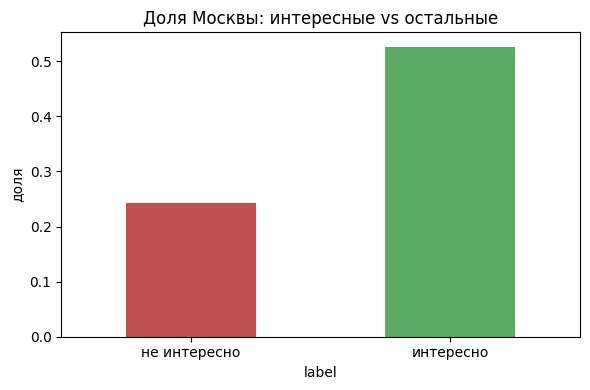

In [5]:
moscow_share = df.groupby('label')['москва'].mean()
moscow_share.rename(index={0:'не интересно',1:'интересно'}, inplace=True)
moscow_share.plot(kind='bar', color=['#c0504d', '#5aab61'], figsize=(6,4))
plt.title('Доля Москвы: интересные vs остальные')
plt.ylabel('доля')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Москва среди интересных - 49%, среди остальных - 23%. Сигнал есть, но слабее типа торгов

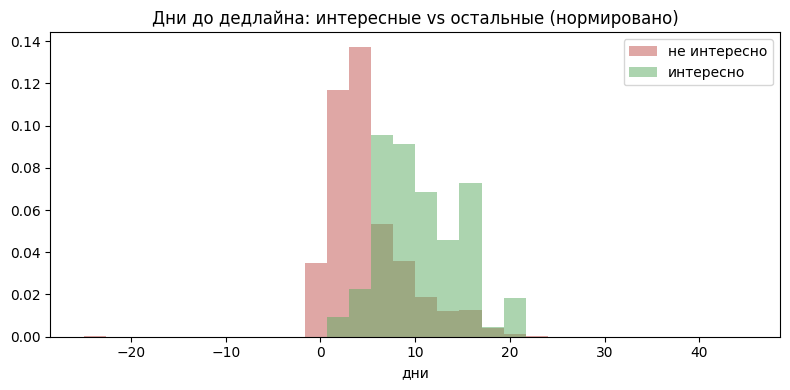

In [6]:
not_int = df[df['label']==0]['дни_до_дедлайна']
interest = df[df['label']==1]['дни_до_дедлайна']

plt.figure(figsize=(8,4))
plt.hist(not_int, bins=30, alpha=0.5, density=True, label='не интересно', color='#c0504d', range=(-25,45))
plt.hist(interest, bins=30, alpha=0.5, density=True, label='интересно', color='#5aab61', range=(-25,45))
plt.title('Дни до дедлайна: интересные vs остальные (нормировано)')
plt.xlabel('дни')
plt.legend()
plt.tight_layout()
plt.show()

У неинтересных огромный пик у 0-2 дней - среди интересных такого пика почти нет, там сроки смещены к 5-15 дням. Признак сам по себе не супер сильный, но можно воспользоваться как доп.

In [7]:
price_share = df.groupby('label')['нмц_указана'].mean()
print(f"Цена указана среди интересных: {price_share[1]*100:.1f}%")
print(f"Цена указана среди остальных: {price_share[0]*100:.1f}%")

Цена указана среди интересных: 49.5%
Цена указана среди остальных: 78.8%


Среди интересных цена указана реже (49%), чем среди остальных (78%). Мне кажется дело не в том, что цена не так важна, а в том, что росто интересные закупки чаще коммерческие/RFI/запрос предложений, где НМЦ на старте часто не публикуют, а малые закупки (где цена почти всегда есть) совсем не интересны

In [8]:
with open('keywords.txt', encoding='utf-8') as f:
    keywords = [w.strip().lower() for w in f if w.strip()]

titles = df[df['label']==1]['Название'].str.lower()
exact_hits = titles.apply(lambda t: any(k in t for k in keywords)).sum()
print(f"{exact_hits} из {len(titles)} интересных закупок содержат точную фразу из keywords.txt")

21 из 95 интересных закупок содержат точную фразу из keywords.txt


Точных фраз почти нет, т.е. заголовки формулируются иначе, чем ключевики шаблона поиска. Значит, нужен стемминг + TF-IDF